# Portfolio Project Part 5: Payment Friction & Financial Risk Analysis
This notebook evaluates transaction performance across payment channels, order statuses, and discount tiers using inferential statistical tests (Chi-Square Test of Independence).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from google.colab import drive

# Mount Drive and load dataset
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/e_commerce_database/'

df_merged = pd.read_csv(os.path.join(base_path, 'orders.csv'))
df_merged.head()

Mounted at /content/drive


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed
3,500004,108780,2024-10-11,2012,1.0,0.1,Gateway,Completed
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed


Status,Cancelled,Completed,Returned
PaymentMethod,,,
CardToCard,612,11035,334
Cash,242,4611,153
Gateway,1162,21945,770
Wallet,447,8088,269


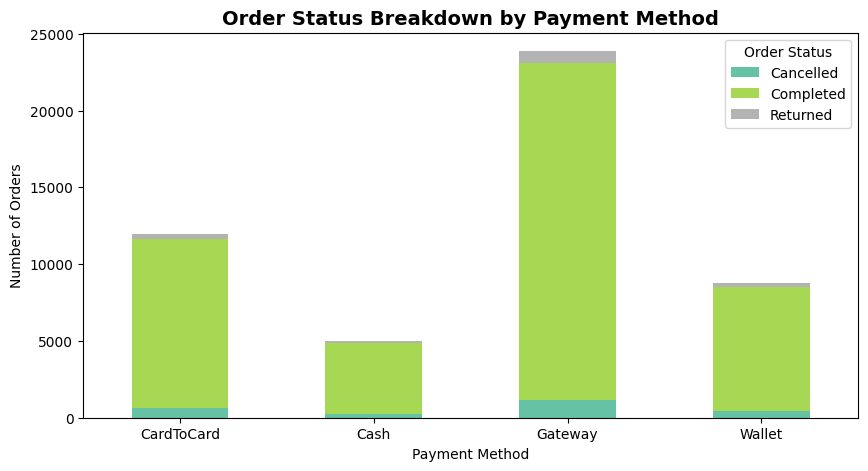

In [2]:
# 1. Summarize Order Volume and Status across Payment Methods
payment_summary = df_merged.groupby(['PaymentMethod', 'Status']).size().unstack(fill_value=0)
display(payment_summary)

# 2. Visualize Order Status Distribution by Payment Method
payment_summary.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Order Status Breakdown by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Order Status')
plt.show()

In [3]:
# Perform Chi-Square Test of Independence (Payment Method vs Order Status)
chi2, p_val, dof, expected = chi2_contingency(payment_summary)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value:              {p_val:.4e}")
print(f"Degrees of Freedom:   {dof}")

if p_val < 0.05:
    print("\nConclusion: Statistically significant relationship between Payment Method and Order Status (p < 0.05).")
else:
    print("\nConclusion: No statistically significant relationship found between Payment Method and Order Status (p >= 0.05).")

--- Chi-Square Test Results ---
Chi-Square Statistic: 6.3860
p-value:              3.8137e-01
Degrees of Freedom:   6

Conclusion: No statistically significant relationship found between Payment Method and Order Status (p >= 0.05).


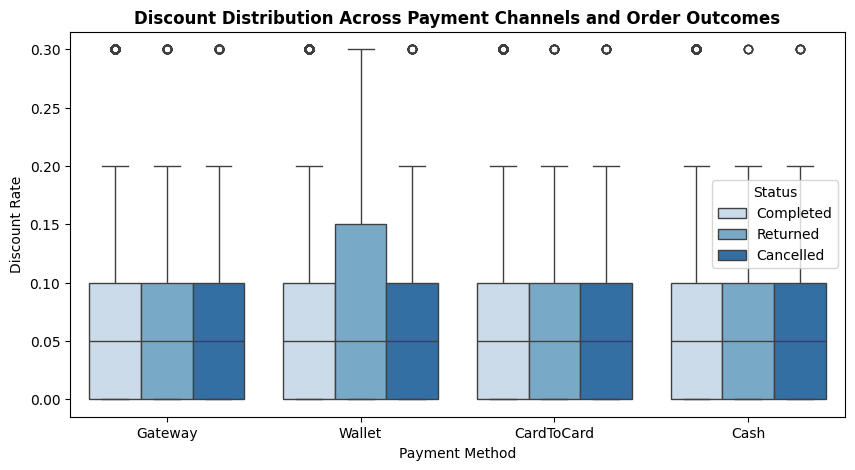

In [4]:
# Analyze Discount Impact on Quantity/Revenue across Payment Channels
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_merged, x='PaymentMethod', y='Discount', hue='Status', palette='Blues')
plt.title('Discount Distribution Across Payment Channels and Order Outcomes', fontsize=12, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Discount Rate')
plt.show()